In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, cross_val_score, train_test_split
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.4600,95.42882,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.7600,13.110001,14.0100,21.910000,0.275,0.318,0.195,0.026,1
1,10.4535,95.42859,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.7535,13.103500,14.0035,21.903500,0.275,0.318,0.195,0.026,1
2,10.4145,95.42721,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.7145,13.064501,13.9645,21.864500,0.275,0.318,0.195,0.026,1
3,9.2235,99.66392,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.4235,12.823500,13.7235,21.923500,0.273,0.324,0.201,0.020,1
4,9.2430,99.66399,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.4430,12.842999,13.7430,21.942999,0.273,0.324,0.201,0.020,1


In [3]:
X=training_df.drop('fire',axis=1)
y=training_df['fire']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Step 3: Initialize and train Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [7]:
# Step 4: K-Fold Cross Validation on Training Set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(logreg, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(f"Logistic Regression 5-Fold CV Mean Accuracy = {np.mean(scores):.4f}")


Logistic Regression 5-Fold CV Mean Accuracy = 0.6542


In [8]:
# Step 4: Predictions
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

# Step 5: Evaluation
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))


Training Accuracy: 0.654572193687168
Testing Accuracy: 0.6571992976294996



Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.67      0.61      0.64     11258
           1       0.65      0.71      0.68     11522

    accuracy                           0.66     22780
   macro avg       0.66      0.66      0.66     22780
weighted avg       0.66      0.66      0.66     22780


Confusion Matrix on Test Set:
[[6823 4435]
 [3374 8148]]


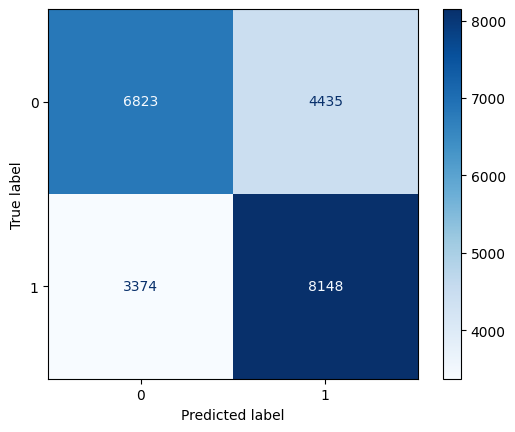

In [9]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix on Test Set:")
print(conf_matrix)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=logreg.classes_)
disp.plot(cmap='Blues')


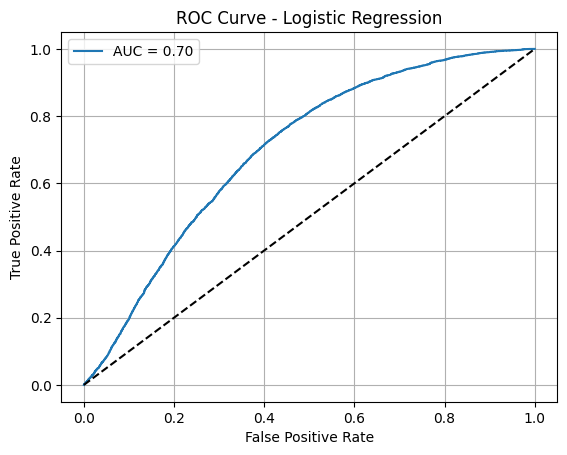

In [10]:
y_probs = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Scale to non-negative values
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
mnb = MultinomialNB()
mnb.fit(X_train_scaled, y_train)

y_train_pred = mnb.predict(X_train_scaled)
y_test_pred = mnb.predict(X_test_scaled)


In [13]:
# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.5534
Testing Accuracy: 0.5550


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.56      0.48      0.52     11258
           1       0.55      0.63      0.59     11522

    accuracy                           0.55     22780
   macro avg       0.56      0.55      0.55     22780
weighted avg       0.56      0.55      0.55     22780

Confusion Matrix on Test Set:
[[5384 5874]
 [4264 7258]]


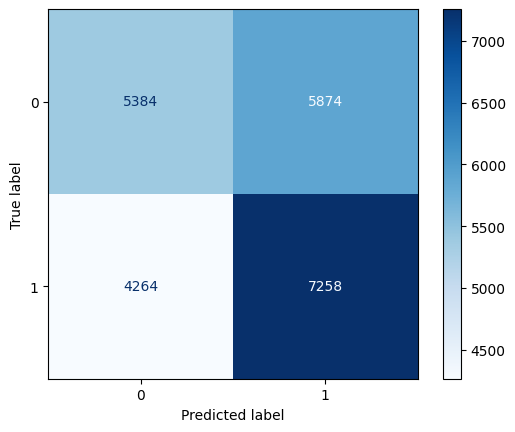

In [14]:
# Classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix on Test Set:")
print(conf_matrix)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=mnb.classes_)
disp.plot(cmap='Blues')


AUC Score: 0.5812


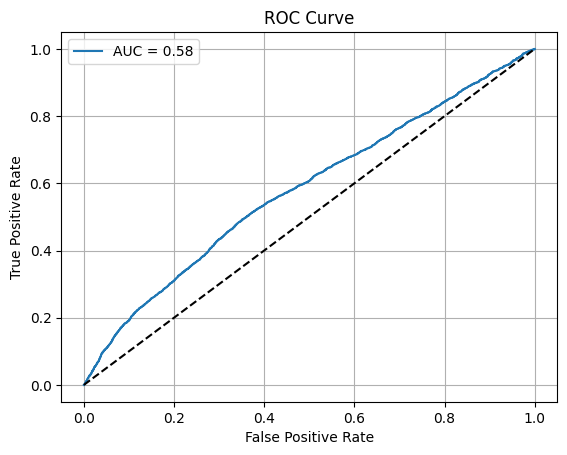

In [15]:
y_probs = mnb.predict_proba(X_test_scaled)[:, 1]  # Get probability estimates for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC Score: {auc_score:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()
